# Évaluation des Modèles

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.fourier import FourierRegressor
from src.models.baselines import AverageRegressor, LastWeekRegressor, YesterdayRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost_regressor import XGBoostRegressor
from src.models.lstm_regressor import LSTMRegressor
from src.models.sarimax import SARIMAXRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

evaluator = TimeSeriesEvaluator(df, "realistic")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, load_existing_splits=True)

CONSUMPTION_COLS = [
    'consommation_mw_tendance_24h_derniere_connue',
    'consommation_mw_tendance_6h_derniere_connue',
    'consommation_mw_min_24h_derniere_connue', 'consommation_mw_max_24h_derniere_connue',
    'consommation_mw_moyenne_24h_derniere_connue',
    'consommation_mw_meme_heure_derniere_connue',
    'consommation_mw_derniere_connue',
    'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
]

CALENDER_COLS = [
    'cible_heure_sin', 'cible_heure_cos',
    'cible_jour_semaine_sin','cible_jour_semaine_cos',
    'cible_jour_annee_sin','cible_jour_annee_cos',
    'heure', 'jour_semaine', 'jour_annee', 'mois', 'saison','saison_meteorologique', 'annee',
    'weekend', 'ferie', 'vacances', 'confinement_numero',
]

TEMPERATURE_COLS = [
	'temperature_c_pondere_pop_meme_heure_derniere_connue',
	'temperature_c_pondere_pop_derniere_connue',
	'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366',
	'temperature_c_pondere_pop_moyenne_24h_derniere_connue',
	'temperature_c_pondere_pop_min_24h_derniere_connue',
	'temperature_c_pondere_pop_max_24h_derniere_connue',
	'temperature_c_pondere_pop_moyenne_48h_derniere_connue',
	'temperature_c_pondere_pop_moyenne_72h_derniere_connue',
	'temperature_c_pondere_pop_tendance_6h_derniere_connue',
	'temperature_c_pondere_pop_tendance_24h_derniere_connue',
	'temperature_c_pondere_pop_sous_15_derniere_connue',
	'temperature_c_pondere_pop_au_dessus_22_derniere_connue',
	'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue',
	'temperature_c_pondere_pop_ecart_normale_derniere_connue'
]

Importing plotly failed. Interactive plots will not work.


## Modèles de Références

In [2]:
# _, best_average = evaluator.grid_search_rolling_validation(AverageRegressor, [{}])
_, best_lastweek = evaluator.grid_search_rolling_validation(LastWeekRegressor, [{}])
_, best_yesterday = evaluator.grid_search_rolling_validation(YesterdayRegressor, [{}])
_, best_linear = evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]]}]
);

Grid Search de LastWeekRegressor :

Combination 1/1 : {}
Évaluation de LastWeekRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3603.92 MW |RMSE = 5263.99 MW |MAPE = 6.51%


Validation : MAE = 3229.23 MW |RMSE = 4845.62 MW |MAPE = 6.05%

Best MAE sur Validation : 3229.23 MW
Best Params : {}

Grid Search de YesterdayRegressor :

Combination 1/1 : {}
Évaluation de YesterdayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3564.97 MW |RMSE = 4974.06 MW |MAPE = 6.88%


Validation : MAE = 3182.98 MW |RMSE = 4362.14 MW |MAPE = 6.40%

Best MAE sur Validation : 3182.98 MW
Best Params : {}

Grid Search de LinearRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'we

In [3]:
_, best_similar = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    {
		"k": [2],
		"temp_weight": [100.0]
	}
);

Grid Search de SimilarDayRegressor :

Combination 1/1 : {'k': 2, 'temp_weight': 100.0}
Évaluation de SimilarDayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 2473.97 MW |RMSE = 3793.92 MW |MAPE = 4.47%


Validation : MAE = 2181.03 MW |RMSE = 3458.58 MW |MAPE = 4.06%

Best MAE sur Validation : 2181.03 MW
Best Params : {'k': 2, 'temp_weight': 100.0}



## Fourier Regression

In [4]:
_, best_fourier = evaluator.grid_search_rolling_validation(
    FourierRegressor,
    [
		{
			"features_cols": [CONSUMPTION_COLS + CALENDER_COLS + TEMPERATURE_COLS],
			"fourier_orders": [{'yearly': 15, 'weekly': 15, 'daily': 15}]
		},
	]
);

Grid Search de FourierRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_tendance_24h_derniere_connue', 'consommation_mw_tendance_6h_derniere_connue', 'consommation_mw_min_24h_derniere_connue', 'consommation_mw_max_24h_derniere_connue', 'consommation_mw_moyenne_24h_derniere_connue', 'consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'cible_heure_sin', 'cible_heure_cos', 'cible_jour_semaine_sin', 'cible_jour_semaine_cos', 'cible_jour_annee_sin', 'cible_jour_annee_cos', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'saison', 'saison_meteorologique', 'annee', 'weekend', 'ferie', 'vacances', 'confinement_numero', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_

# Prophet

In [5]:
_, best_prophet = evaluator.grid_search_rolling_validation(
    ProphetRegressor,
    [
		{
			"history_days": [3 * 366],
			"features_cols": [TEMPERATURE_COLS]
        }
    ]
);

Grid Search de ProphetRegressor :

Combination 1/1 : {'features_cols': ['temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_pondere_pop_min_24h_derniere_connue', 'temperature_c_pondere_pop_max_24h_derniere_connue', 'temperature_c_pondere_pop_moyenne_48h_derniere_connue', 'temperature_c_pondere_pop_moyenne_72h_derniere_connue', 'temperature_c_pondere_pop_tendance_6h_derniere_connue', 'temperature_c_pondere_pop_tendance_24h_derniere_connue', 'temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue', 'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue', 'temperature_c_pondere_pop_ecart_normale_derniere_connue'], 'history_days': 1098}
Évaluation de ProphetRegressor | 8784 lignes | réentraînement/6ME | 3 itérations


10:32:22 - cmdstanpy - INFO - Chain [1] start processing
10:32:25 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

10:32:36 - cmdstanpy - INFO - Chain [1] start processing
10:32:40 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-31 00:00...

10:32:56 - cmdstanpy - INFO - Chain [1] start processing
10:33:00 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-07-31 00:00...
Train : MAE = 2130.10 MW |RMSE = 2789.28 MW |MAPE = 4.11%


Validation : MAE = 2085.42 MW |RMSE = 2708.47 MW |MAPE = 4.18%

Best MAE sur Validation : 2085.42 MW
Best Params : {'features_cols': ['temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_pondere_pop_min_24h_derniere_connue', 'temperature_c_pondere_pop_max_24h_derniere_connue', 'temperature_c_pondere_pop_moyenne_48h_derniere_connue', 'temperature_c_pondere_pop_moyenne_72h_derniere_connue', 'temperature_c_pondere_pop_tendance_6h_derniere_connue', 'temperature_c_pondere_pop_tendance_24h_derniere_connue', 'temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue', 'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue', 'temperature_c_pondere_pop_ec

# XGBoost

In [6]:
_, best_xgb = evaluator.grid_search_rolling_validation(
    XGBoostRegressor,
    [{}]
);

Grid Search de XGBoostRegressorCustom :

Combination 1/1 : {}
Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/6ME | 3 itérations

Nombre d'arbres réellement retenus (best_iteration) : 412 / 3000
Meilleure MAE validation : 1802.21
Progression: 2024-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 557 / 3000
Meilleure MAE validation : 2566.43
Progression: 2024-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 290 / 3000
Meilleure MAE validation : 598.28
Progression: 2024-07-31 00:00...
Train : MAE = 1134.28 MW |RMSE = 1602.50 MW |MAPE = 2.11%


Validation : MAE = 1342.85 MW |RMSE = 1904.00 MW |MAPE = 2.60%

Best MAE sur Validation : 1342.85 MW
Best Params : {}



# SARIMAX

In [7]:
import itertools

p = [2]
d = [0]
q = [2]
orders = list(itertools.product(p, d, q))

P = [1]
D = [1]
Q = [1]
seasonal_orders = [(*x, 24) for x in itertools.product(P, D, Q)]

_, best_sarimax = evaluator.grid_search_rolling_validation(SARIMAXRegressor, [
	{
		"order": orders,
		"seasonal_order": seasonal_orders,
		"features_cols": [[
		    'consommation_mw_moins_365', 'consommation_mw_moins_366',
			'cible_jour_semaine_sin','cible_jour_semaine_cos',
			'cible_jour_annee_sin','cible_jour_annee_cos',
			'annee', 'weekend', 'ferie', 'vacances', 'confinement_numero',
			'temperature_c_pondere_pop_meme_heure_derniere_connue',
			'temperature_c_pondere_pop_derniere_connue',
			'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366',
			'temperature_c_pondere_pop_sous_15_derniere_connue',
			'temperature_c_pondere_pop_au_dessus_22_derniere_connue',
			'temperature_c_pondere_pop_ecart_normale_derniere_connue'
		]],
		"num_years": [1]
	}
]);

Grid Search de SARIMAXRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_moins_365', 'consommation_mw_moins_366', 'cible_jour_semaine_sin', 'cible_jour_semaine_cos', 'cible_jour_annee_sin', 'cible_jour_annee_cos', 'annee', 'weekend', 'ferie', 'vacances', 'confinement_numero', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue', 'temperature_c_pondere_pop_ecart_normale_derniere_connue'], 'num_years': 1, 'order': (2, 0, 2), 'seasonal_order': (1, 1, 1, 24)}
Évaluation de SARIMAXRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 1703.29 MW |RMSE = 4157.83 MW |MAPE = 2.93%


Validation : MAE = 5396.31 MW |RMSE = 6605.60 MW |MAPE = 11.18%

Best MAE sur Validation : 5396.31 MW
Best Params 

# LSTM

In [8]:
_, best_lstm = evaluator.grid_search_rolling_validation(
	LSTMRegressor,
	[{}],
);

Grid Search de LSTMRegressor :

Combination 1/1 : {}
Évaluation de LSTMRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2024-01-01 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2024-01-31 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2024-07-31 00:00...
Train : MAE = 1162.23 MW |RMSE = 1667.55 MW |MAPE = 2.11%


Validation : MAE = 1192.08 MW |RMSE = 1706.97 MW |MAPE = 2.29%

Best MAE sur Validation : 1192.08 MW
Best Params : {}



# Test

In [9]:
# evaluator.rolling_test(best_average["model"]);
evaluator.rolling_test(best_lastweek["model"]);
evaluator.rolling_test(best_yesterday["model"]);
evaluator.rolling_test(best_linear["model"]);
evaluator.rolling_test(best_fourier["model"]);
evaluator.rolling_test(best_prophet["model"]);
evaluator.rolling_test(best_xgb["model"]);
evaluator.rolling_test(best_similar["model"]);
evaluator.rolling_test(best_sarimax["model"]);
evaluator.rolling_test(best_lstm["model"]);

Test évaluation de LastWeekRegressor
Évaluation de LastWeekRegressor | 15313 lignes | réentraînement/6ME | 5 itérations
Progression: 2026-07-31 00:00...
Validation : MAE = 3404.25 MW |RMSE = 4961.62 MW |MAPE = 6.45%

Test évaluation de YesterdayRegressor
Évaluation de YesterdayRegressor | 15313 lignes | réentraînement/6ME | 5 itérations
Progression: 2026-07-31 00:00...
Validation : MAE = 3080.10 MW |RMSE = 4251.83 MW |MAPE = 6.22%

Test évaluation de LinearRegressor
Évaluation de LinearRegressor | 15313 lignes | réentraînement/6ME | 5 itérations
Progression: 2026-07-31 00:00...
Validation : MAE = 2178.62 MW |RMSE = 2824.58 MW |MAPE = 4.34%

Test évaluation de FourierRegressor
Évaluation de FourierRegressor | 15313 lignes | réentraînement/6ME | 5 itérations
Progression: 2026-07-31 00:00...
Validation : MAE = 1477.38 MW |RMSE = 2015.75 MW |MAPE = 2.91%

Test évaluation de ProphetRegressor
Évaluation de ProphetRegressor | 15313 lignes | réentraînement/6ME | 5 itérations


10:56:22 - cmdstanpy - INFO - Chain [1] start processing
10:56:25 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2025-01-01 00:00...

10:56:28 - cmdstanpy - INFO - Chain [1] start processing
10:56:29 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2025-01-31 00:00...

...

Progression: 2026-07-31 00:00...
Validation : MAE = 1888.09 MW |RMSE = 2514.05 MW |MAPE = 3.76%

Test évaluation de XGBoostRegressorCustom
Évaluation de XGBoostRegressorCustom | 15313 lignes | réentraînement/6ME | 5 itérations

Nombre d'arbres réellement retenus (best_iteration) : 566 / 3000
Meilleure MAE validation : 2163.74
Progression: 2025-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 822 / 3000
Meilleure MAE validation : 2310.13
Progression: 2025-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 1583 / 3000
Meilleure MAE validation : 1009.07
Progression: 2025-07-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 641 / 3000
Meilleure MAE validation : 2039.14
Progression: 2026-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 804 / 3000
Meilleure MAE validation : 1368.82
Progression: 2026-07-31 00:00...
Validation : MAE = 1271.31 MW |RMSE = 1810.52 MW |MAPE = 2.45%

Test évaluation de SimilarDayRegressor
Éva

e:\Projects\Studies\ElectricityConsumption\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Progression: 2026-01-31 00:00...

e:\Projects\Studies\ElectricityConsumption\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Progression: 2026-07-31 00:00...
Validation : MAE = 4469.70 MW |RMSE = 5487.20 MW |MAPE = 9.20%

Test évaluation de LSTMRegressor
Évaluation de LSTMRegressor | 15313 lignes | réentraînement/6ME | 5 itérations
modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2025-01-01 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2025-01-31 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2025-07-31 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2026-01-31 00:00...modèle 1/5 entraîné
modèle 2/5 entraîné
modèle 3/5 entraîné
modèle 4/5 entraîné
modèle 5/5 entraîné
Progression: 2026-07-31 00:00...
Validation : MAE = 1260.46 MW |RMSE = 1750.91 MW |MAPE = 2.44%



## Visualisation

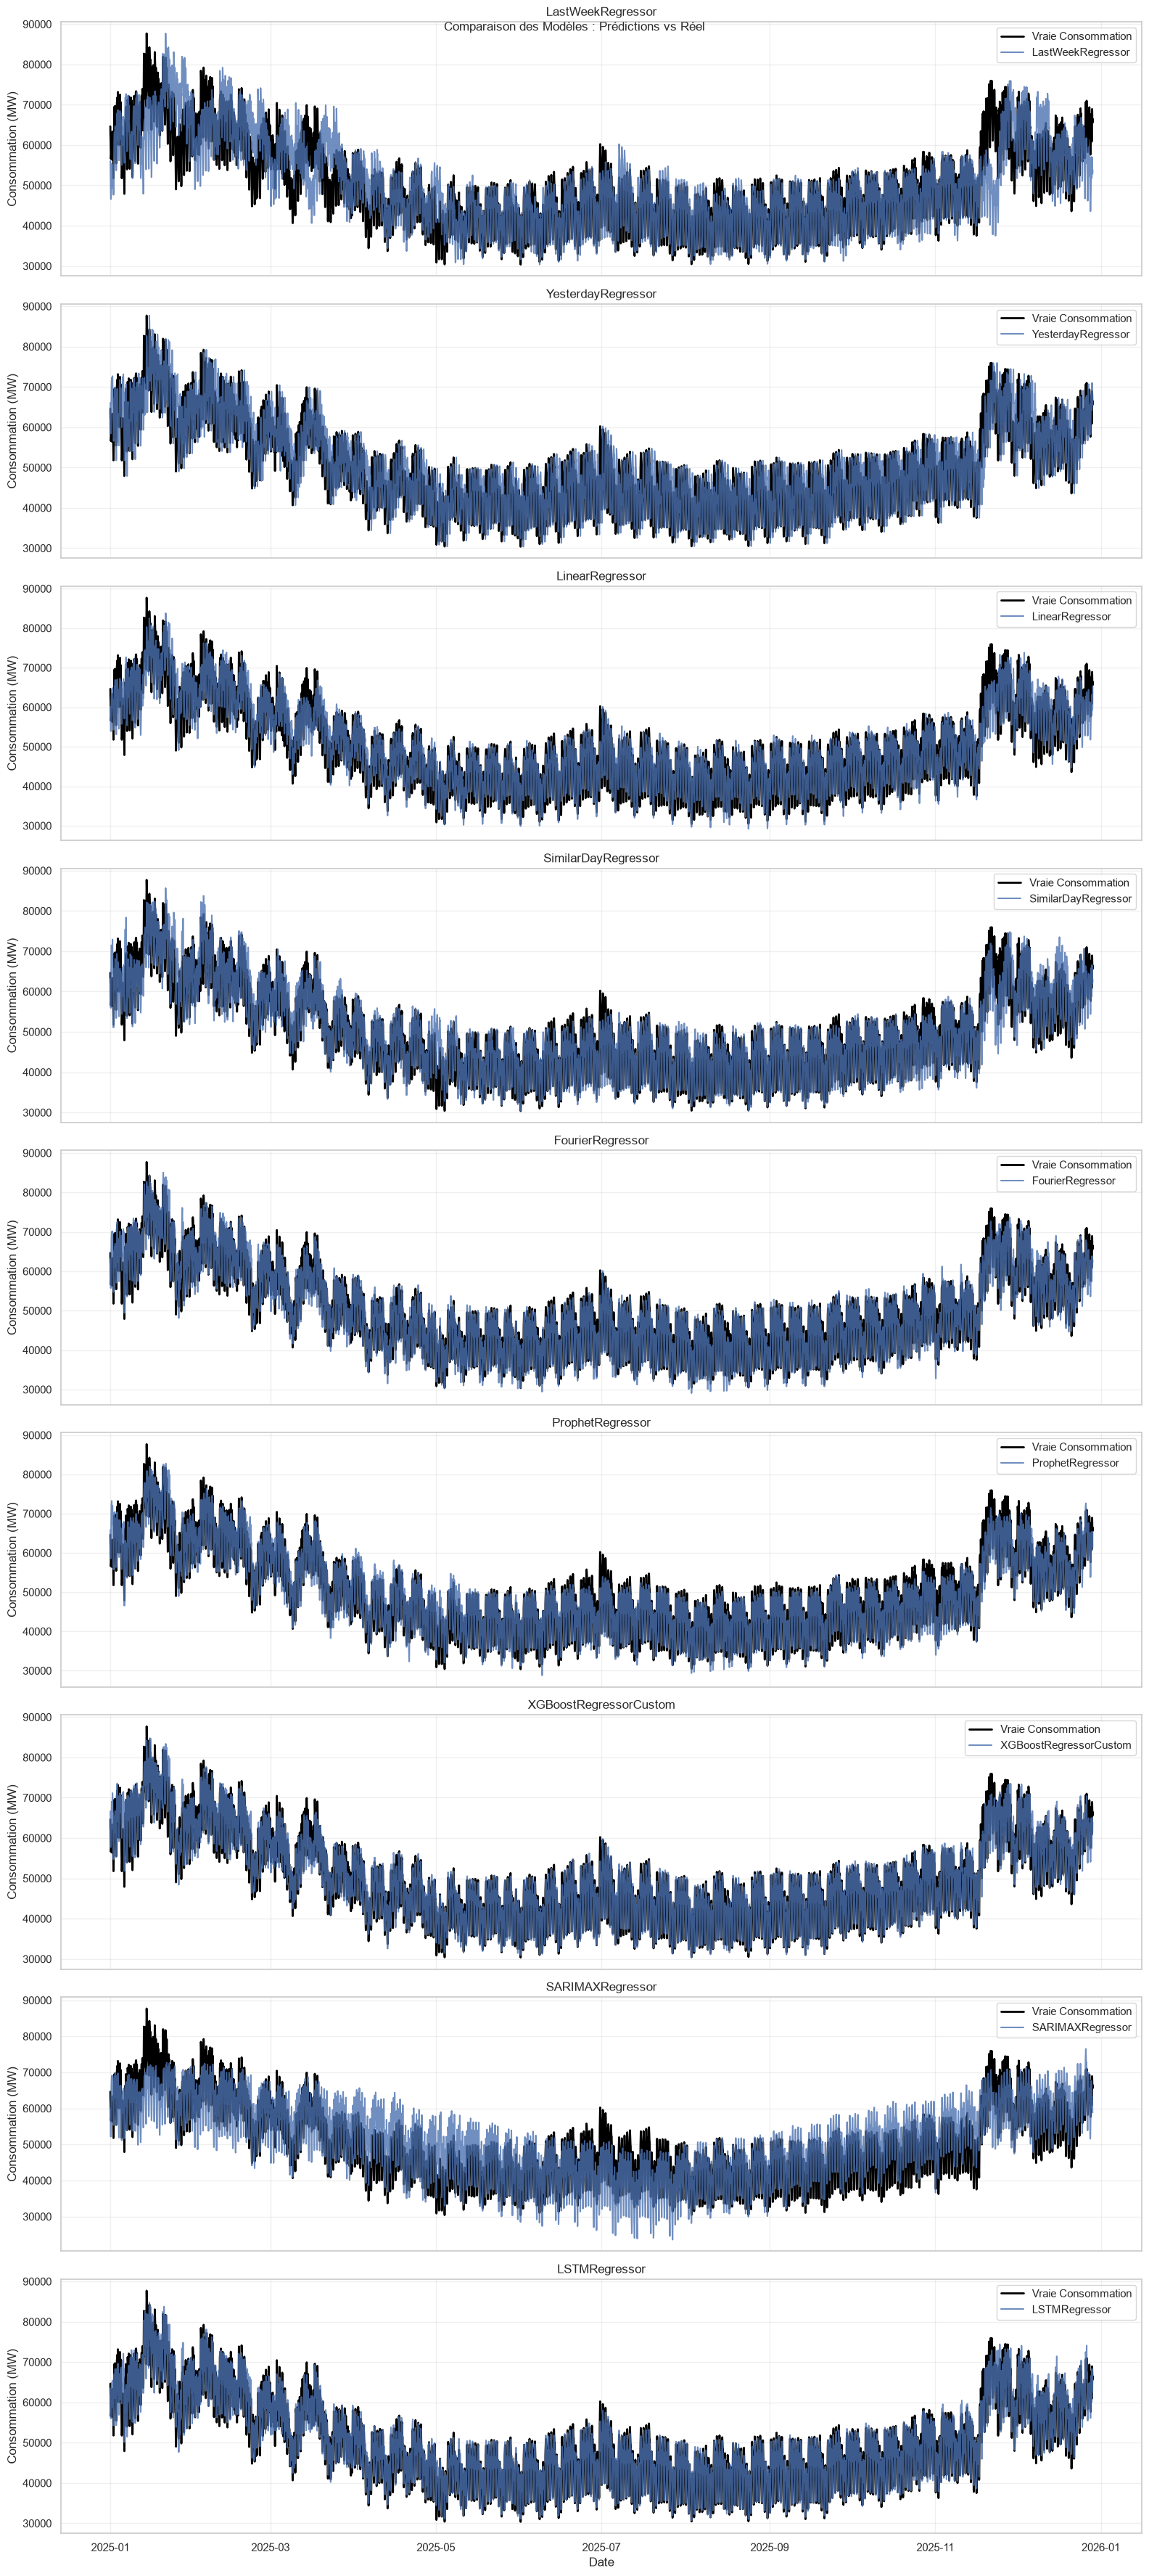

In [17]:
# Zoomons sur le mois de Janvier 2025
start_zoom = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2025-12-29').tz_localize('Europe/Paris')

evaluator.plot_predictions(use_test=True, start_date=start_zoom, end_date=end_zoom)

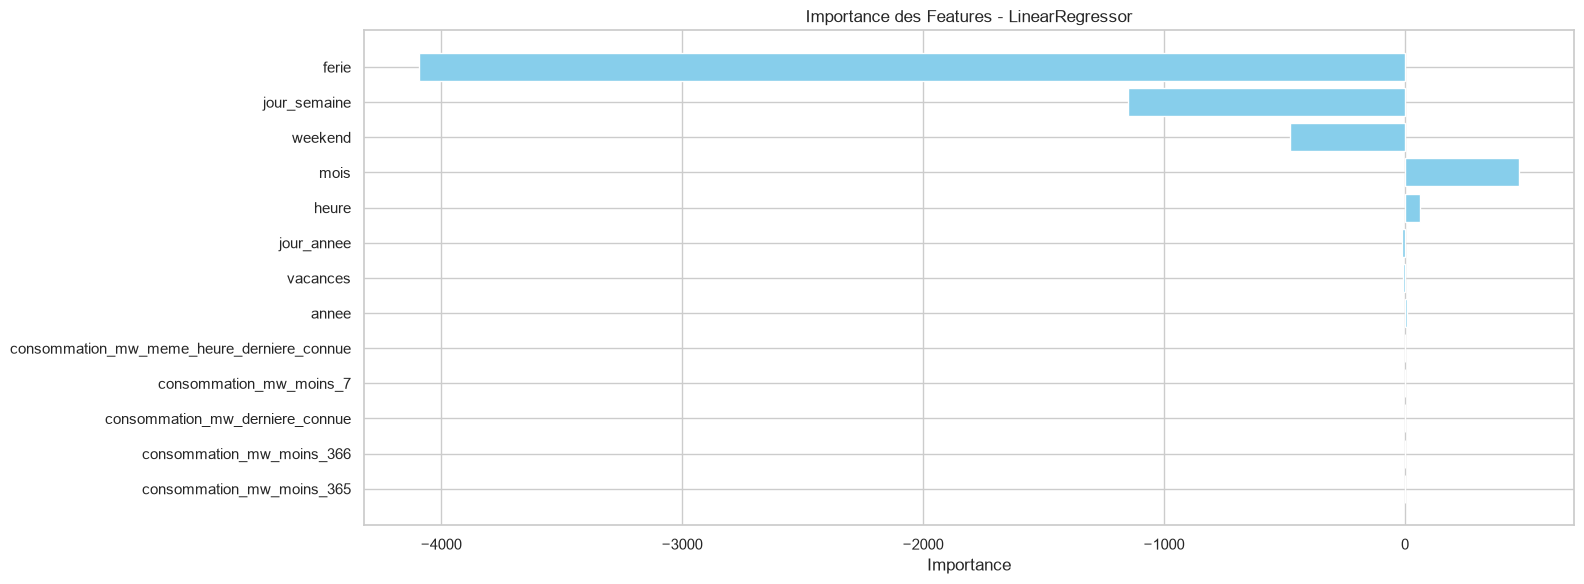

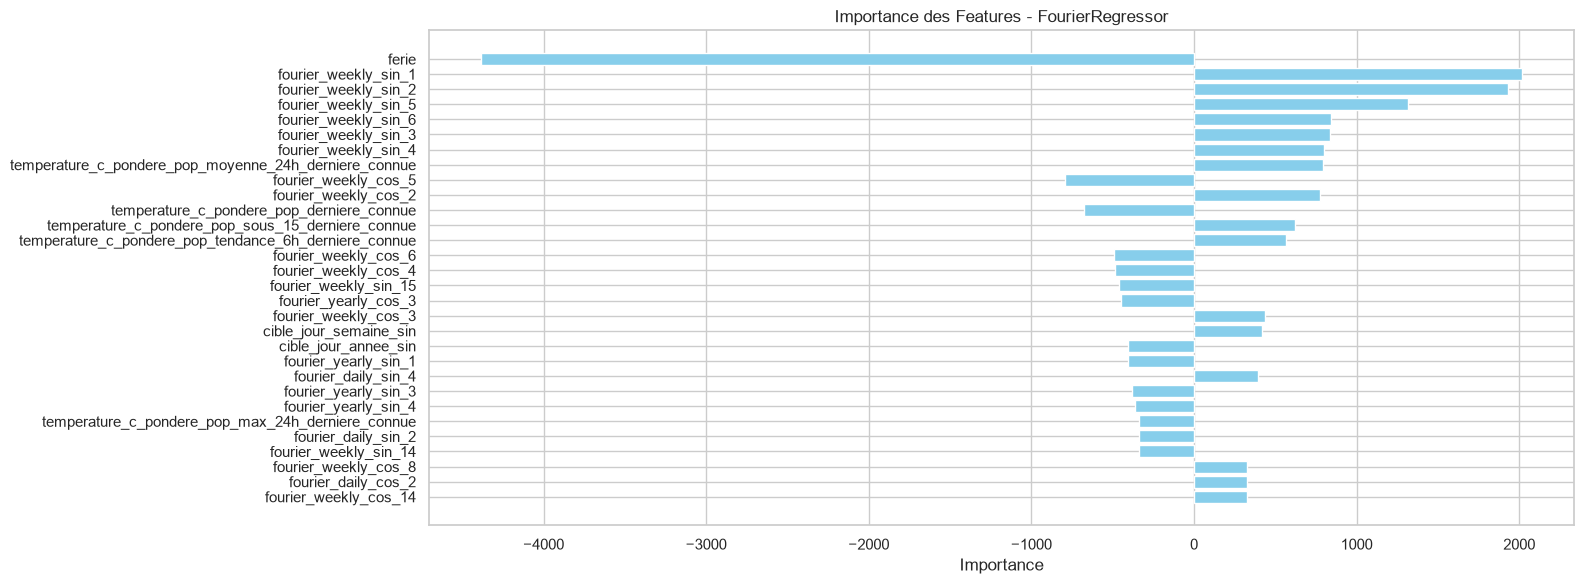

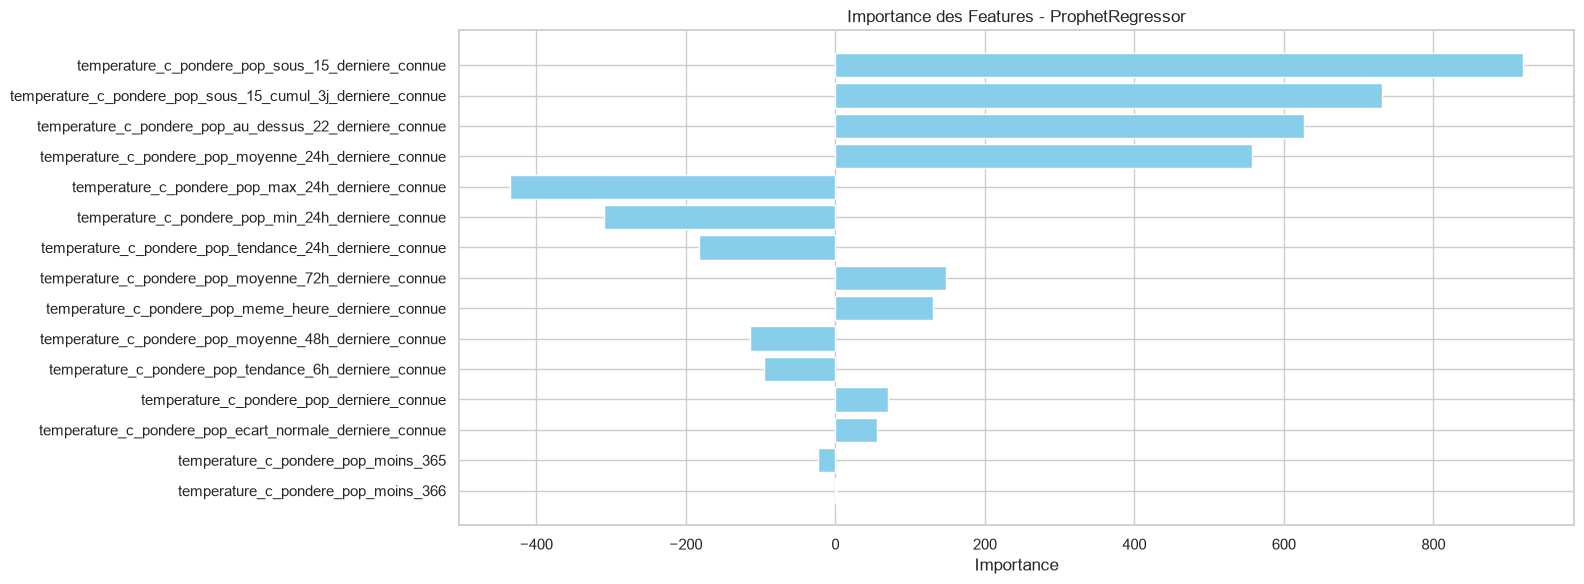

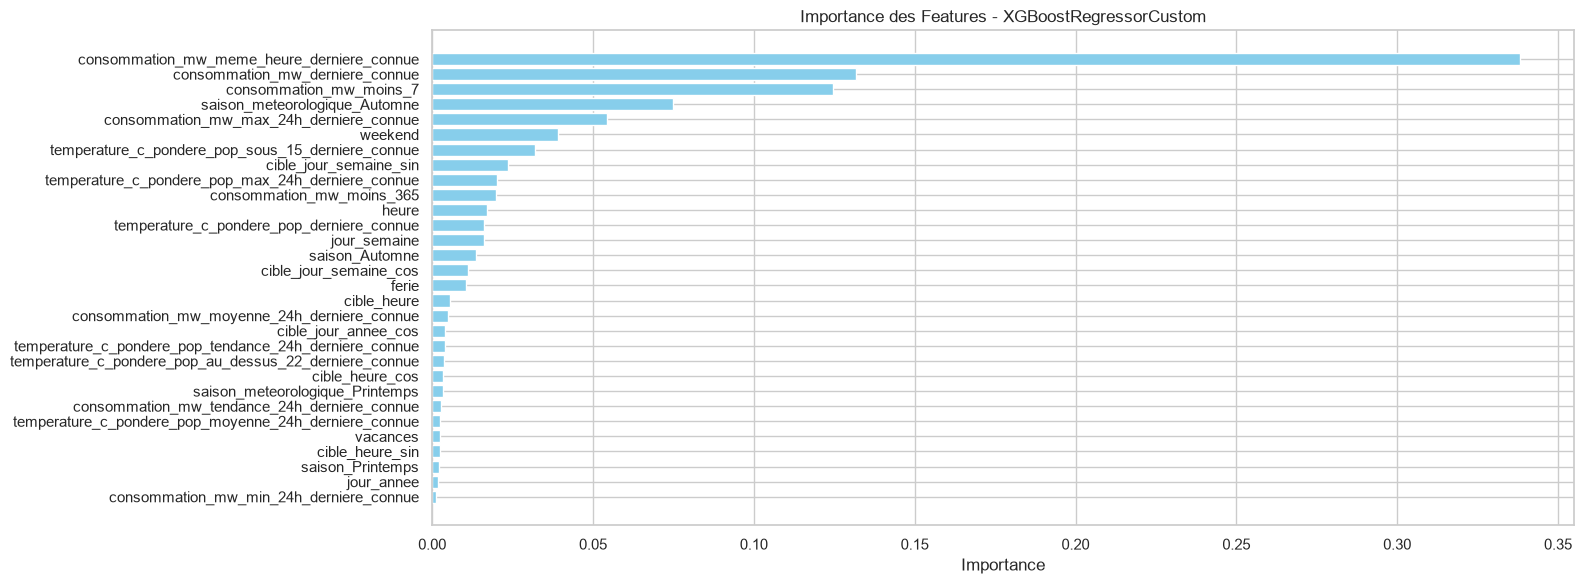

In [11]:
evaluator.plot_feature_importances(top_n=30)

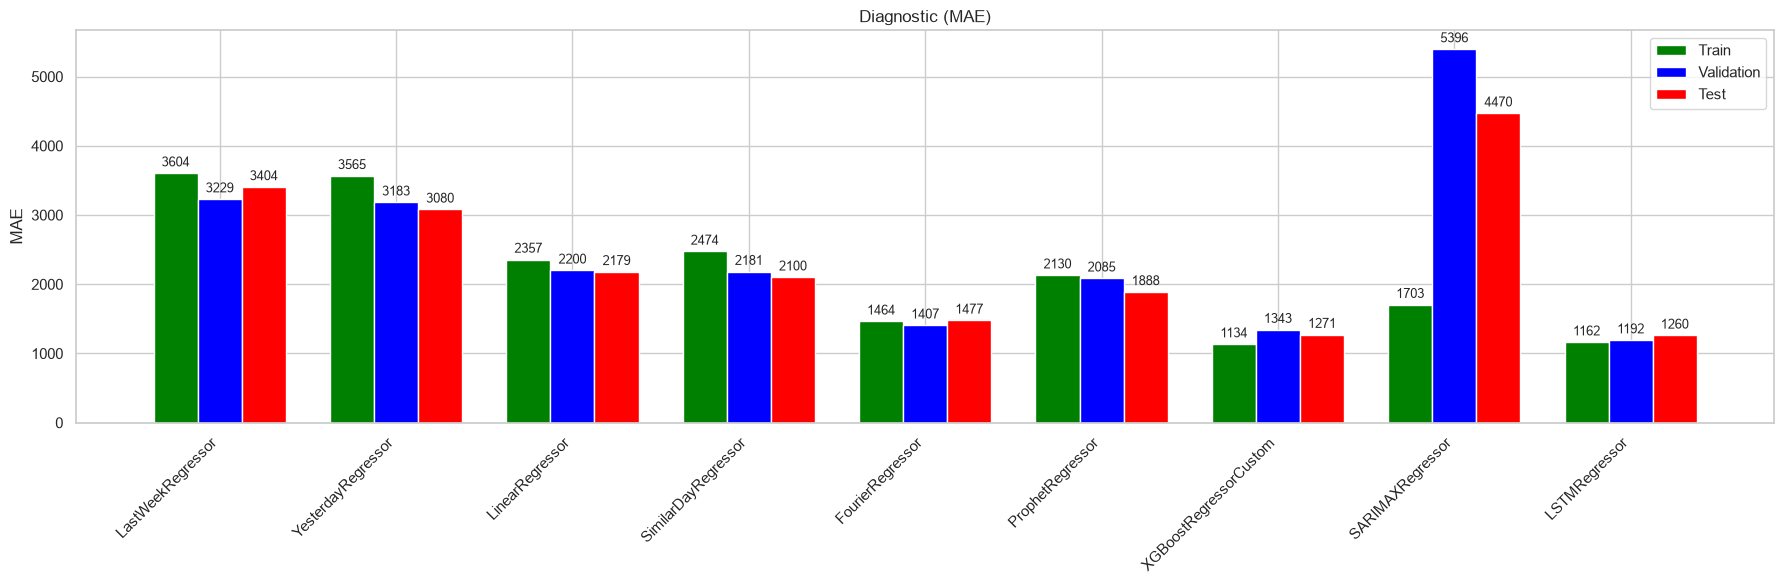

In [12]:
evaluator.plot_train_val_test_metrics()

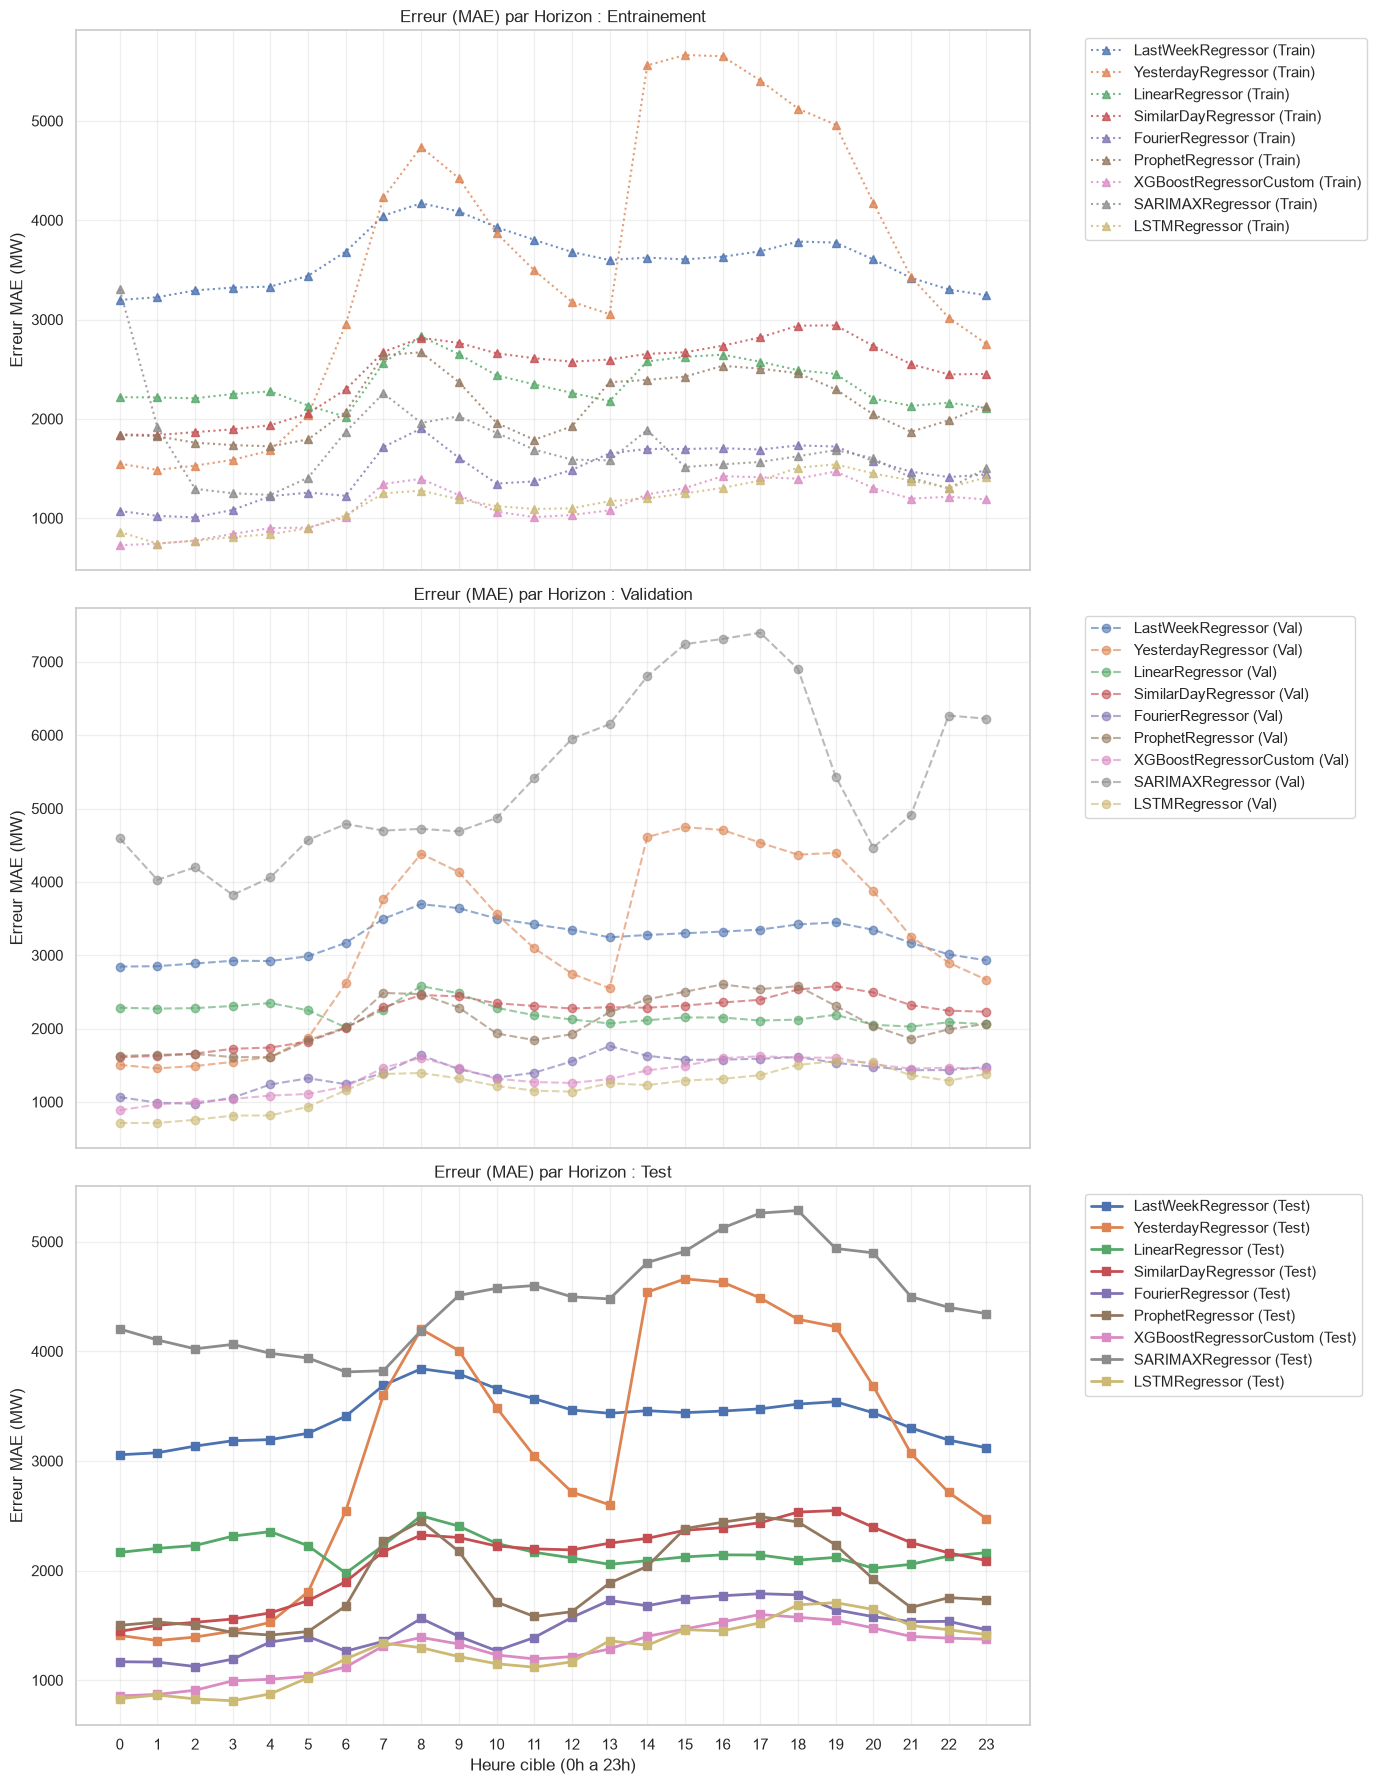

In [13]:
evaluator.plot_error_per_horizon()

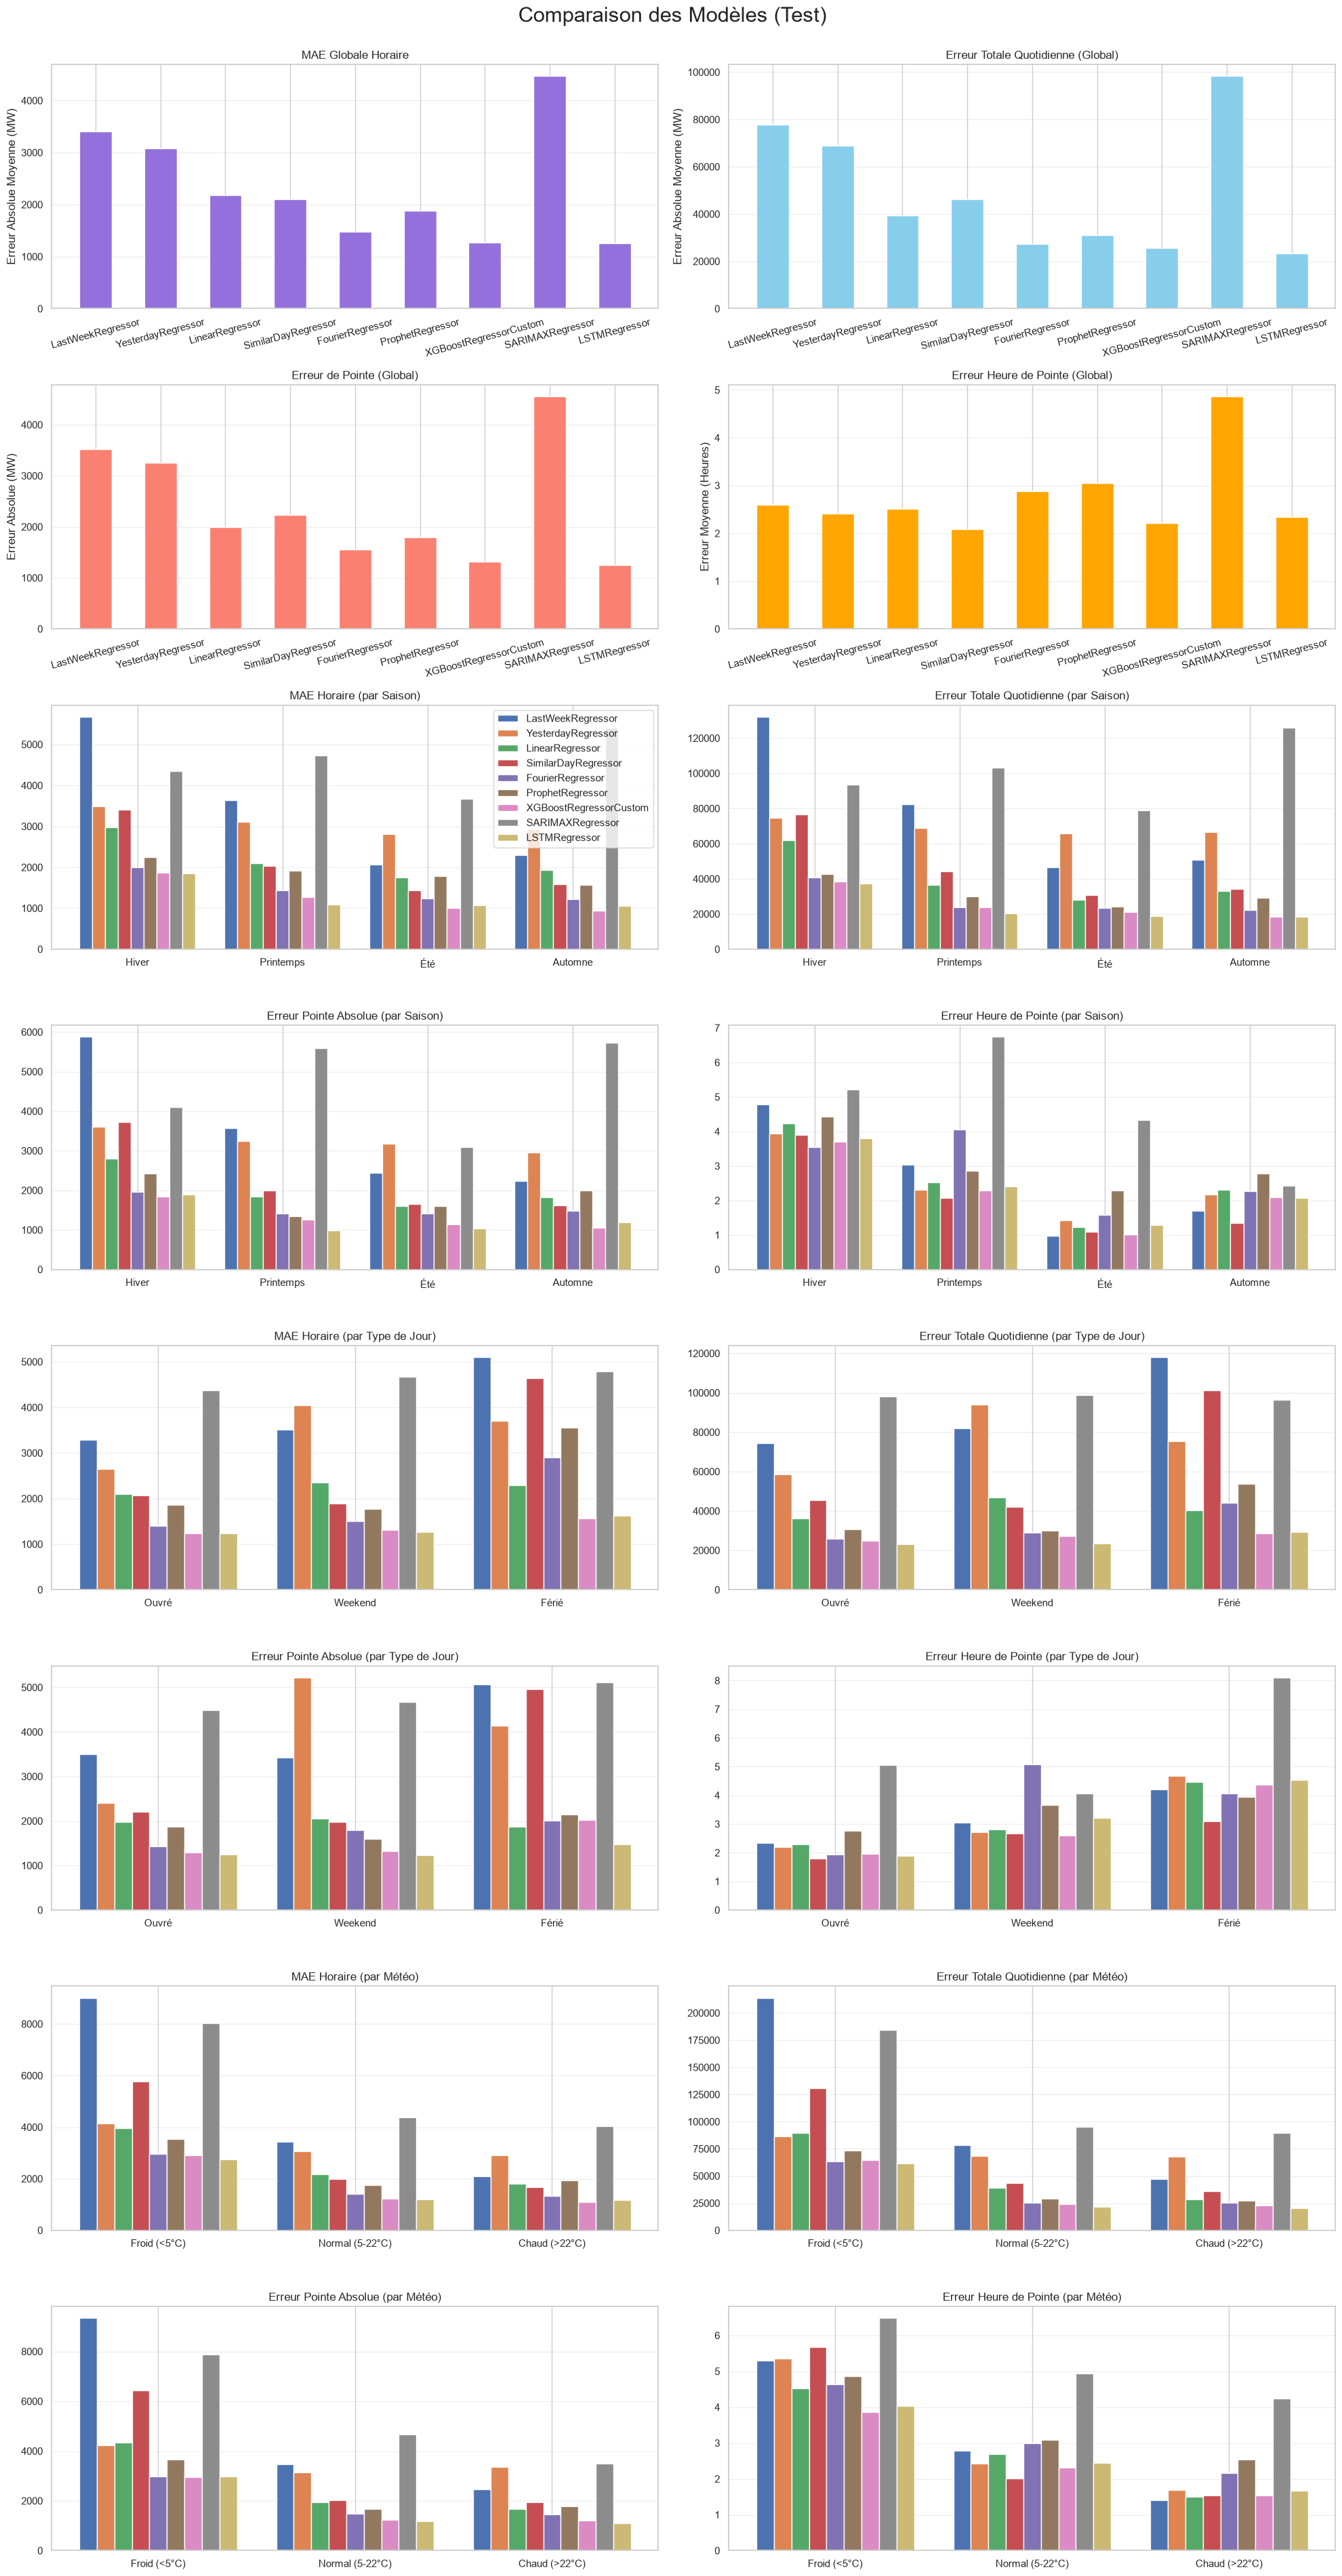

In [14]:
evaluator.plot_advanced_metrics()

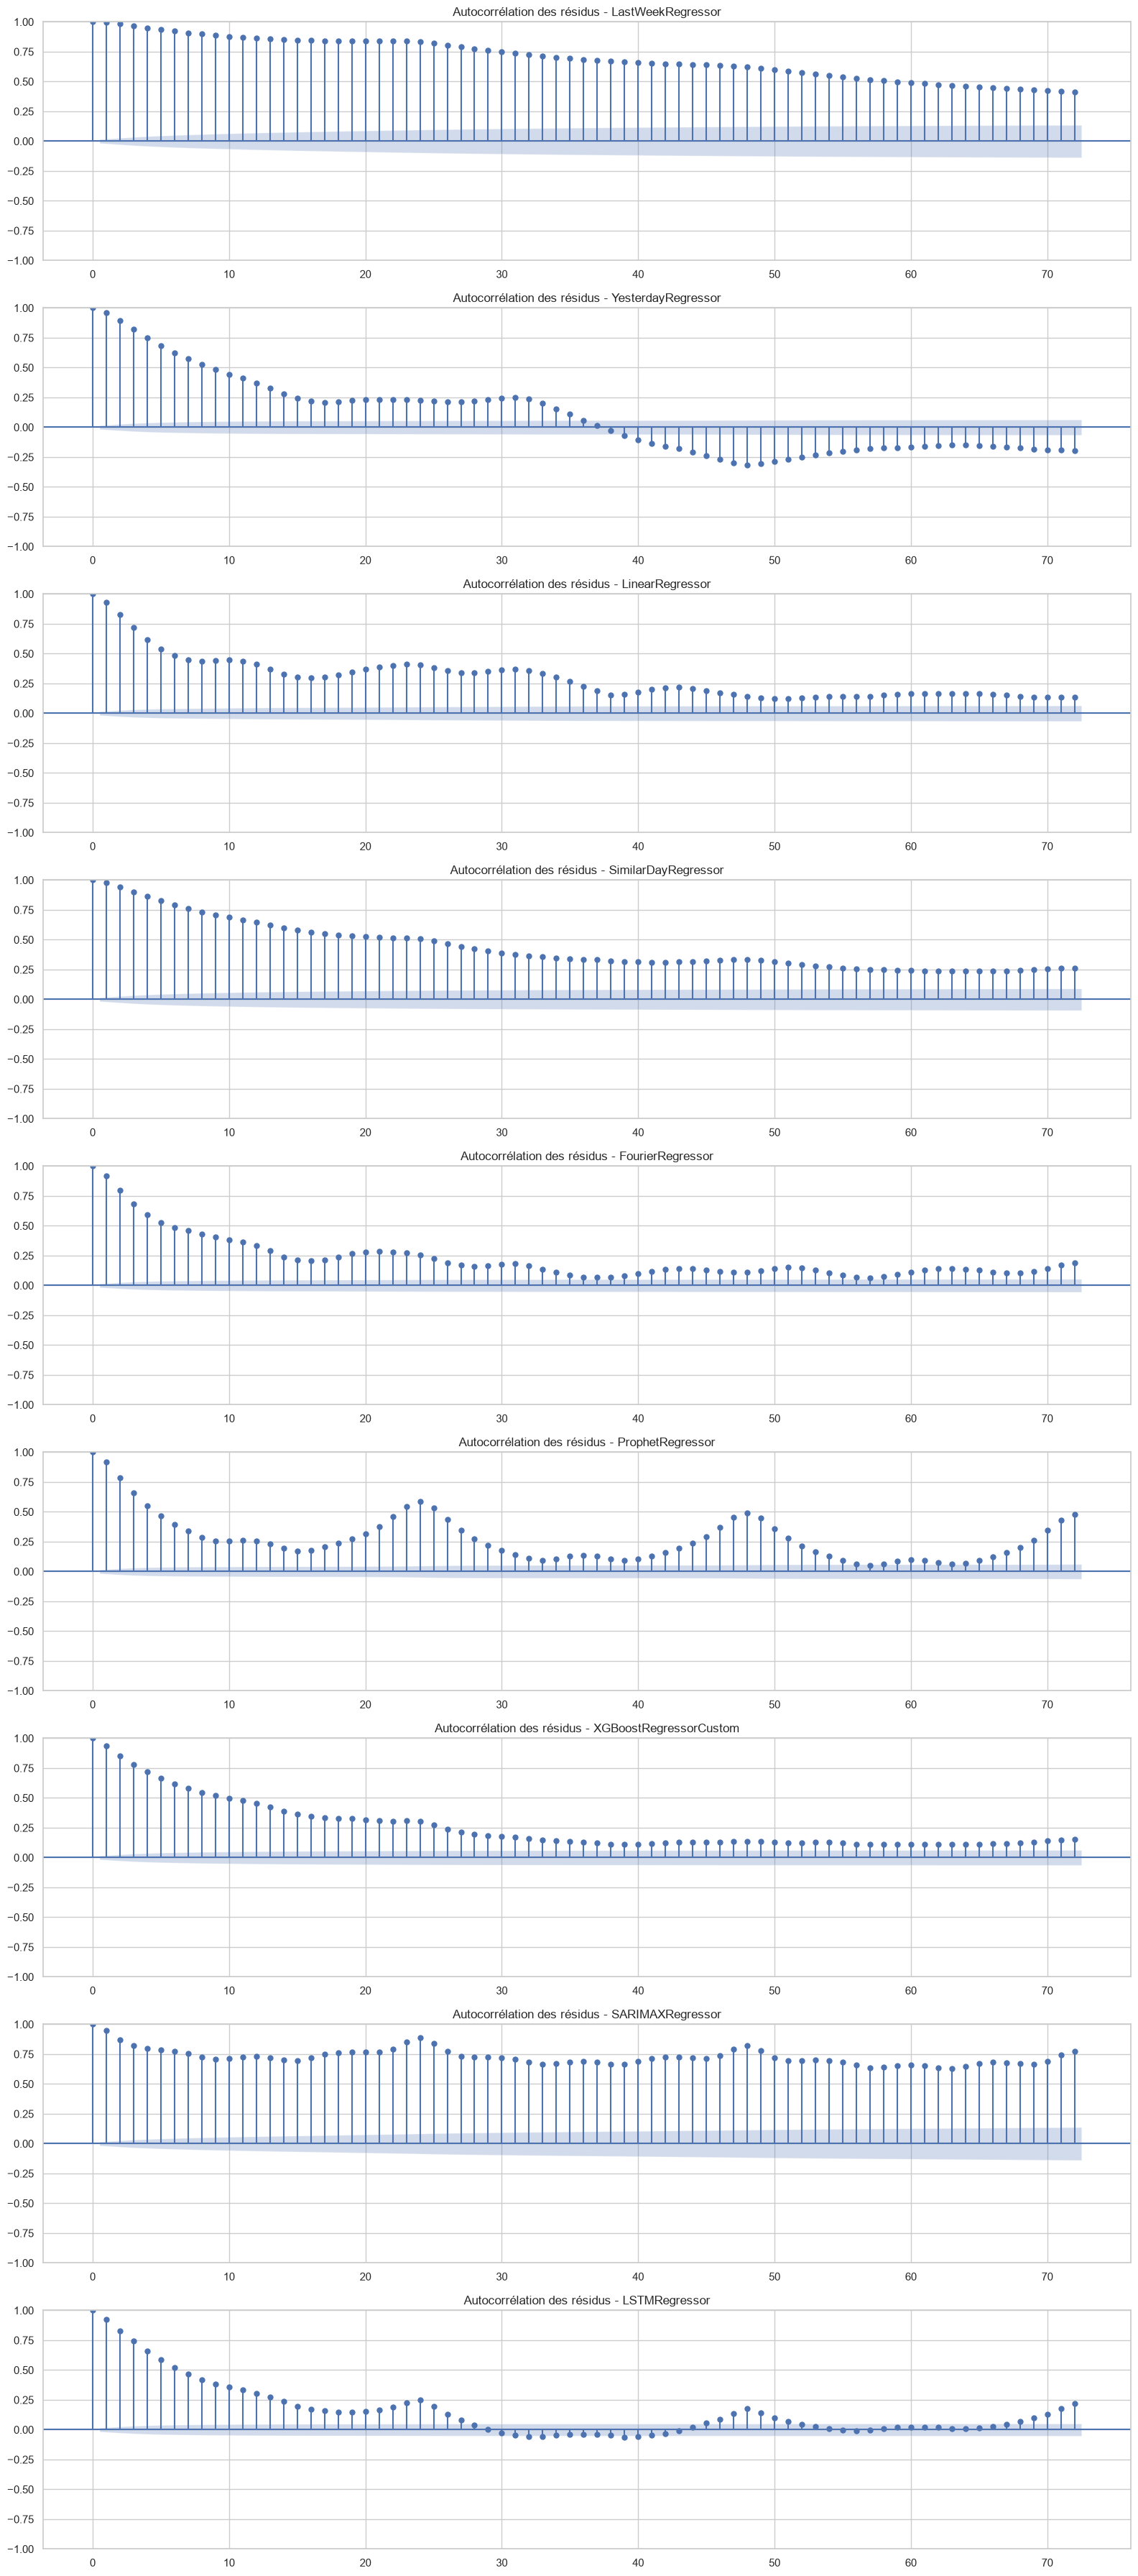


Test de Ljung-Box (Hypothèse nulle : les résidus sont distribués indépendamment)


,Modèle,Q-Stat (Lag 24),p-value (Lag 24),Q-Stat (Lag 48),p-value (Lag 48)
0,LastWeekRegressor,287169.009178,0.0,468019.007189,0.0
1,YesterdayRegressor,89797.240652,0.0,104305.629920,0.0
2,LinearRegressor,86751.409126,0.0,113788.254742,0.0
3,SimilarDayRegressor,173014.856881,0.0,221325.728314,0.0
4,FourierRegressor,69772.238525,0.0,76819.362102,0.0
5,ProphetRegressor,68483.905359,0.0,94487.027885,0.0
6,XGBoostRegressorCustom,99975.248127,0.0,109209.179279,0.0
7,SARIMAXRegressor,221185.389862,0.0,412602.905694,0.0
8,LSTMRegressor,68647.903341,0.0,71005.823397,0.0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Calcul des résidus et test de Ljung-Box pour chaque modèle
results_ljungbox = []

models_with_preds = {k: v for k, v in evaluator.models.items() if 'test_preds' in v}
n_models = len(models_with_preds)

fig, axes = plt.subplots(n_models, 1, figsize=(16, 4 * n_models))
if n_models == 1:
    axes = [axes]

for i, (name, data) in enumerate(models_with_preds.items()):
    y_true = evaluator.df_test[evaluator.target_col].values
    y_pred = np.array(data['test_preds'])
    resid = y_true - y_pred
    resid = resid[~np.isnan(resid)]

    # ACF Plot
    plot_acf(resid, lags=72, ax=axes[i], title=f"Autocorrélation des résidus - {name}")

    # Ljung-Box test up to lag 24 and 48
    lb_test = acorr_ljungbox(resid, lags=[24, 48], return_df=True)

    results_ljungbox.append({
        "Modèle": name,
        "Q-Stat (Lag 24)": lb_test['lb_stat'].iloc[0],
        "p-value (Lag 24)": lb_test['lb_pvalue'].iloc[0],
        "Q-Stat (Lag 48)": lb_test['lb_stat'].iloc[1],
        "p-value (Lag 48)": lb_test['lb_pvalue'].iloc[1]
    })

plt.tight_layout()
plt.show()

# Affichage du tableau Ljung-Box
df_lb = pd.DataFrame(results_ljungbox)
print("\nTest de Ljung-Box (Hypothèse nulle : les résidus sont distribués indépendamment)")
display(df_lb)